## Inicialización

In [ ]:
# Cargar todas las librerías
import pandas as pd
import numpy as np
from scipy import stats as st
import math as mt
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

## Cargar datos

In [ ]:
# Carga los archivos de datos en diferentes DataFrames
c
df_internet = pd.read_csv('/datasets/megaline_internet.csv', sep = ',')
df_messages = pd.read_csv('/datasets/megaline_messages.csv', sep = ',')
df_plans = pd.read_csv('/datasets/megaline_plans.csv', sep = ',')
df_users = pd.read_csv('/datasets/megaline_users.csv', sep = ',')

## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [ ]:
# Imprime una muestra de los datos para las tarifas
df_plans.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
df_plans.duplicated().sum()

0

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Usuarios/as

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Imprime una muestra de datos para usuarios
df_users.sample(n=100, random_state=1)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
304,1304,Dominque,Cole,69,"Birmingham-Hoover, AL MSA",2018-10-28,ultimate,NaN
340,1340,Vanna,Stanton,65,"Dallas-Fort Worth-Arlington, TX MSA",2018-07-05,surf,NaN
47,1047,Yuk,French,22,"Indianapolis-Carmel-Anderson, IN MSA",2018-06-16,ultimate,NaN
67,1067,Robt,Allen,37,"Grand Rapids-Kentwood, MI MSA",2018-09-24,surf,2018-11-24
479,1479,Keesha,Burnett,44,"Riverside-San Bernardino-Ontario, CA MSA",2018-11-12,surf,NaN
...,...,...,...,...,...,...,...,...
11,1011,Halina,Henry,73,"Cleveland-Elyria, OH MSA",2018-01-18,ultimate,NaN
192,1192,Korey,Goodwin,36,"Buffalo-Cheektowaga, NY MSA",2018-10-02,surf,NaN
92,1092,Taren,Strickland,26,"Dallas-Fort Worth-Arlington, TX MSA",2018-12-10,surf,NaN
221,1221,Mckenzie,Wilkinson,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-12-17,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]
La información del dataset esta completa, el tipo de información es acorde con lo se especifica en cada columna. La única diferencia puntualmente es en la columna "churn_date" que es la fecha del uso del servicio, sin embargo, se hace la salvedad que no tiene información ya que es un servicio que se encuentra en uso.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
#duplicados
df_users.duplicated().sum()

0

In [ ]:
#valores faltantes
df_users.isnull().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    object        
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


## Llamadas

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Imprime una muestra de datos para las llamadas
df_calls.sample(n=100, random_state=1)


,id,user_id,call_date,duration
106231,1374_327,1374,2018-12-17,1.17
109017,1385_87,1385,2018-10-20,14.02
76096,1268_600,1268,2018-09-24,12.21
106317,1375_219,1375,2018-12-03,7.03
98706,1354_6,1354,2018-10-16,6.21
...,...,...,...,...
43277,1157_306,1157,2018-09-13,0.05
123188,1434_530,1434,2018-11-24,0.96
85862,1316_106,1316,2018-08-14,0.00
110172,1389_209,1389,2018-05-27,0.00


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]
En términos de información general esta completa, es decir, no hay valores ausentes, el tipo de dato esta acorde a lo que contiene la información. Al ser una muestra de datos aleatorios, no se evidencia un patrón en los datos, ya que tomó valores de todos los meses y asi como las duraciones de las llamadas, ya que efectivamente no son similares de un usuario a otro.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
#duplicados
df_calls.duplicated().sum()

0

In [ ]:
#valores faltantes
df_calls.isnull().sum()

id           0
user_id      0
call_date    0
duration     0
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
df_calls['duration_min'] = (df_calls['duration'] / 60).round(1)

In [ ]:
df_calls.head()

,id,user_id,call_date,duration,duration_min
0,1000_93,1000,2018-12-27,8.52,0.1
1,1000_145,1000,2018-12-27,13.66,0.2
2,1000_247,1000,2018-12-27,14.48,0.2
3,1000_309,1000,2018-12-28,5.76,0.1
4,1000_380,1000,2018-12-30,4.22,0.1


## Mensajes

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Imprime una muestra de datos para los mensajes
df_messages.sample(n=100, random_state=1)

,id,user_id,message_date
12922,1084_162,1084,2018-11-17
55949,1354_99,1354,2018-10-04
19111,1123_180,1123,2018-11-04
46123,1314_11,1314,2018-12-15
72141,1467_473,1467,2018-05-18
...,...,...,...
68088,1439_482,1439,2018-08-19
42689,1280_207,1280,2018-08-09
4309,1043_484,1043,2018-07-27
30785,1193_553,1193,2018-08-05


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]
En el dataset la información esta completa, son 76051 entradas de información y por columnas estan los tipos de datos que corresponden, no se evidenció valores ausentes ni tampoco tipos de datos no adecuados.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
#duplicados
df_messages.duplicated().sum()

0

In [ ]:
#valores faltantes
df_messages.isnull().sum()

id              0
user_id         0
message_date    0
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

#extraer mes
df_messages['month'] = df_messages['message_date'].dt.month
display(df_messages.head())


,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


## Internet

In [ ]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Imprime una muestra de datos para el tráfico de internet
df_internet.sample(n=100, random_state=1)

,id,user_id,session_date,mb_used
13106,1062_76,1062,2018-09-15,225.79
70950,1331_201,1331,2018-09-28,169.69
6195,1035_43,1035,2018-12-27,124.84
2400,1011_140,1011,2018-06-26,0.00
25926,1121_19,1121,2018-12-16,504.92
...,...,...,...,...
27480,1127_153,1127,2018-10-17,234.15
77582,1362_258,1362,2018-06-17,626.75
29544,1134_474,1134,2018-10-23,172.67
19378,1088_72,1088,2018-10-18,319.08


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]
Todos los datos de la información esta con su tipo de dato acorde y no se evidencia valores ausentes.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [ ]:
#duplicados
df_internet.duplicated().sum()

0

In [ ]:
#valores faltantes
df_internet.isnull().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [ ]:
df_internet['gb_used'] = (df_internet['mb_used'] / 1024).round(4)
display(df_internet.head())

,id,user_id,session_date,mb_used,gb_used
0,1000_13,1000,2018-12-29,89.86,0.0878
1,1000_204,1000,2018-12-31,0.00,0.0000
2,1000_379,1000,2018-12-28,660.40,0.6449
3,1000_413,1000,2018-12-26,270.99,0.2646
4,1000_442,1000,2018-12-27,880.22,0.8596


In [ ]:
#df_internet.query("user_id == 1482 and month == 10")

In [ ]:
df_internet['month'] = pd.to_datetime(df_internet['session_date']).dt.month
display(df_internet.head())

,id,user_id,session_date,mb_used,gb_used,month
0,1000_13,1000,2018-12-29,89.86,0.0878,12
1,1000_204,1000,2018-12-31,0.00,0.0000,12
2,1000_379,1000,2018-12-28,660.40,0.6449,12
3,1000_413,1000,2018-12-26,270.99,0.2646,12
4,1000_442,1000,2018-12-27,880.22,0.8596,12


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [ ]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [ ]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            137735 non-null  object 
 1   user_id       137735 non-null  int64  
 2   call_date     137735 non-null  object 
 3   duration      137735 non-null  float64
 4   duration_min  137735 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 5.3+ MB


In [ ]:
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            137735 non-null  object        
 1   user_id       137735 non-null  int64         
 2   call_date     137735 non-null  datetime64[ns]
 3   duration      137735 non-null  float64       
 4   duration_min  137735 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 5.3+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Los datos fueron revisados y modificados apropiadamente, ahora se puede empezar a trabajar con ellos comodamente
</div>


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [ ]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], errors='coerce')
df_calls['month'] = df_calls['call_date'].dt.month
calls_per_month = (df_calls.groupby(['user_id', 'month'])['id'].count().reset_index(name='calls_count'))
display(calls_per_month.head())


,user_id,month,calls_count
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


In [ ]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
df_calls['month'] = df_calls['call_date'].dt.month
minuts_per_month= df_calls.groupby(['user_id', 'month'])['duration_min'].sum().reset_index(name='minutes_used')
print(minuts_per_month.head())

   user_id  month  minutes_used
0     1000     12           1.9
1     1001      8           2.8
2     1001      9           4.8
3     1001     10           6.2
4     1001     11           6.4


In [ ]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
df_messages['month'] = df_messages['message_date'].dt.month
messages_per_user_month = df_messages.groupby(['user_id', 'month'])["id"].count().reset_index(name='messages_count')
display(messages_per_user_month.head())


,user_id,month,messages_count
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


In [ ]:
#df_messages.query("user_id == 1482 and month == 10")

In [ ]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
df_internet['month'] = pd.to_datetime(df_internet['session_date']).dt.month
total_internet= df_internet.groupby(['user_id', 'month'])['gb_used'].sum().reset_index(name="internet_counting")
display(total_internet.head())

,user_id,month,internet_counting
0,1000,12,1.8569
1,1001,8,6.7570
2,1001,9,13.0027
3,1001,10,21.8072
4,1001,11,18.0706


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [ ]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month

#calls
df_calls['month'] = pd.to_datetime(df_calls['call_date']).dt.month

calls_month = df_calls.groupby(["user_id","month"])["id"].count().reset_index(name="call_counting")
display(calls_month.head())

#messages
df_messages['month'] = pd.to_datetime(df_messages['message_date']).dt.month

messages_month = df_messages.groupby(["user_id","month"])["id"].count().reset_index(name="messages_counting")
display(messages_month.head())

#internet
df_internet['month'] = pd.to_datetime(df_internet['session_date']).dt.month

internet_month = df_internet.groupby(["user_id","month"])["id"].count().reset_index(name="internet_counting")
display(internet_month.head())

#minuts
df_calls['month'] = pd.to_datetime(df_calls['call_date']).dt.month

min_calls = df_calls.groupby(['user_id', 'month'])['duration_min'].sum().reset_index(name="minuts_calls")
display(min_calls.head())

#unir mensajes y llamadas
calls_and_messages = pd.merge(calls_month, messages_month, on = ["user_id", "month"], how= "outer")
display(calls_and_messages.head())

#unir minutos e internet
min_and_internet = pd.merge(min_calls, internet_month, on = ["user_id", "month"], how= "outer")
display(min_and_internet.head())

#consumo total

total_consumo=  pd.merge(calls_and_messages, min_and_internet, on = ["user_id", "month"], how= "outer")
display(total_consumo.head())



,user_id,month,call_counting
0,1000,12,16
1,1001,8,27
2,1001,9,49
3,1001,10,65
4,1001,11,64


,user_id,month,messages_counting
0,1000,12,11
1,1001,8,30
2,1001,9,44
3,1001,10,53
4,1001,11,36


,user_id,month,internet_counting
0,1000,12,5
1,1001,8,25
2,1001,9,53
3,1001,10,56
4,1001,11,51


,user_id,month,minuts_calls
0,1000,12,1.9
1,1001,8,2.8
2,1001,9,4.8
3,1001,10,6.2
4,1001,11,6.4


,user_id,month,call_counting,messages_counting
0,1000,12,16.0,11.0
1,1001,8,27.0,30.0
2,1001,9,49.0,44.0
3,1001,10,65.0,53.0
4,1001,11,64.0,36.0


,user_id,month,minuts_calls,internet_counting
0,1000,12,1.9,5.0
1,1001,8,2.8,25.0
2,1001,9,4.8,53.0
3,1001,10,6.2,56.0
4,1001,11,6.4,51.0


,user_id,month,call_counting,messages_counting,minuts_calls,internet_counting
0,1000,12,16.0,11.0,1.9,5.0
1,1001,8,27.0,30.0,2.8,25.0
2,1001,9,49.0,44.0,4.8,53.0
3,1001,10,65.0,53.0,6.2,56.0
4,1001,11,64.0,36.0,6.4,51.0


In [ ]:
# Añade la información de la tarifa
total_consumo.head()

,user_id,month,call_counting,messages_counting,minuts_calls,internet_counting
0,1000,12,16.0,11.0,1.9,5.0
1,1001,8,27.0,30.0,2.8,25.0
2,1001,9,49.0,44.0,4.8,53.0
3,1001,10,65.0,53.0,6.2,56.0
4,1001,11,64.0,36.0,6.4,51.0


In [ ]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT


In [ ]:
df_plans = df_plans.rename(columns={"plan_name":"plan"})
display(df_plans.head())

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [ ]:
usuarios_tarifa = pd.merge(df_users, df_plans,on = "plan", how="left")
display(usuarios_tarifa.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000,30720,3000,70,7,0.01,0.01
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaT,50,15360,500,20,10,0.03,0.03
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaT,50,15360,500,20,10,0.03,0.03
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaT,50,15360,500,20,10,0.03,0.03


In [ ]:
full_users= pd.merge(total_consumo, usuarios_tarifa, on = "user_id", how="left")
display(full_users.head())

,user_id,month,call_counting,messages_counting,minuts_calls,internet_counting,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,12,16.0,11.0,1.9,5.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaT,1000,30720,3000,70,7,0.01,0.01
1,1001,8,27.0,30.0,2.8,25.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
2,1001,9,49.0,44.0,4.8,53.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
3,1001,10,65.0,53.0,6.2,56.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03
4,1001,11,64.0,36.0,6.4,51.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaT,50,15360,500,20,10,0.03,0.03


In [ ]:
full_users.columns

full_users_ajustado= full_users[['user_id','month', 'first_name', 'last_name', 'age',
       'city', 'reg_date', 'plan', 'churn_date', 'messages_included',
       'mb_per_month_included', 'minutes_included', 'usd_monthly_pay',
       'usd_per_gb', 'usd_per_message', 'usd_per_minute','call_counting', 'messages_counting',
       'minuts_calls', 'internet_counting',]].fillna(0)
display(full_users_ajustado.head())

,user_id,month,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,call_counting,messages_counting,minuts_calls,internet_counting
0,1000,12,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,0,1000,30720,3000,70,7,0.01,0.01,16.0,11.0,1.9,5.0
1,1001,8,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,27.0,30.0,2.8,25.0
2,1001,9,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,49.0,44.0,4.8,53.0
3,1001,10,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,65.0,53.0,6.2,56.0
4,1001,11,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,64.0,36.0,6.4,51.0


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [ ]:
def get_montly_income(df_x) :

    conteo_mensajes = df_x["messages_counting"] - df_x["messages_included"]
    conteo_internet = df_x["internet_counting"] - df_x["mb_per_month_included"]/1024
    conteo_minutos = df_x["minuts_calls"] - df_x["minutes_included"]

    if conteo_mensajes <= 0 :
         conteo_mensajes = 0

    if conteo_internet <= 0 :
         conteo_internet = 0

    if conteo_minutos <= 0 :
         conteo_minutos = 0

    df_x["ingreso_mensual"] = df_x["usd_monthly_pay"] + conteo_mensajes * df_x["usd_per_message"] + \
    conteo_internet * df_x["usd_per_gb"] + conteo_minutos * df_x["usd_per_minute"]


    return df_x


In [ ]:
  full_users_ajustado_2 = full_users_ajustado.apply(get_montly_income, axis=1)
  display(full_users_ajustado_2.head())

,user_id,month,first_name,last_name,age,city,reg_date,plan,churn_date,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,call_counting,messages_counting,minuts_calls,internet_counting,ingreso_mensual
0,1000,12,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,0,1000,30720,3000,70,7,0.01,0.01,16.0,11.0,1.9,5.0,70.00
1,1001,8,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,27.0,30.0,2.8,25.0,120.00
2,1001,9,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,49.0,44.0,4.8,53.0,400.00
3,1001,10,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,65.0,53.0,6.2,56.0,430.09
4,1001,11,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,0,50,15360,500,20,10,0.03,0.03,64.0,36.0,6.4,51.0,380.00


In [ ]:
full_users_ajustado_2["ingreso_mensual"].value_counts()

70.00     139
20.00     138
370.00     39
400.00     34
390.00     34
         ... 
770.00      1
300.39      1
220.03      1
20.09       1
220.84      1
Name: ingreso_mensual, Length: 459, dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de agregar los datos por usuario, ahora tenemos columnas extras que nos ayudarán con el analisis posterior
</div>


## Estudia el comportamiento de usuario

### Llamadas

In [ ]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
calls_users = pd.merge(df_calls, df_users, on='user_id', how='left')

calls_full = pd.merge(calls_users, df_plans, left_on='plan', right_on='plan', how='left')

calls_full['month'] = calls_full['call_date'].dt.month

average_duration = (calls_full.groupby(['plan', 'month'])['duration'].mean().reset_index(name='average_duration')
)

display(average_duration.head())

,plan,month,average_duration
0,surf,1,6.428000
1,surf,2,6.906175
2,surf,3,6.696919
3,surf,4,6.799918
4,surf,5,6.769200


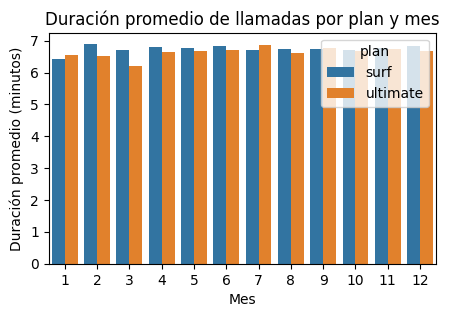

In [ ]:
plt.figure(figsize=(5,3))
sns.barplot(
    data=average_duration,
    x='month',
    y='average_duration',
    hue='plan'
)

plt.title('Duración promedio de llamadas por plan y mes')
plt.xlabel('Mes')
plt.ylabel('Duración promedio (minutos)')
plt.show()

In [ ]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
calls_users = pd.merge(df_calls,df_users, on='user_id', how='left')

monthly_minutes = (calls_users.groupby(['user_id', 'plan', 'month'])['duration'].sum().reset_index(name='total_minutes')
)
display(monthly_minutes.head())

,user_id,plan,month,total_minutes
0,1000,ultimate,12,116.83
1,1001,surf,8,171.14
2,1001,surf,9,297.69
3,1001,surf,10,374.11
4,1001,surf,11,404.59


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [ ]:
# Calcula la media y la varianza de la duración mensual de llamadas.

monthly_minutes = (df_calls.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='total_monthly_duration'))

mean_duration = monthly_minutes['total_monthly_duration'].mean()
var_duration = monthly_minutes['total_monthly_duration'].var()

display(f"Media de duración mensual: {mean_duration} minutos")
display(f"Varianza de duración mensual: {var_duration}")


'Media de duración mensual: 411.4925863596103 minutos'

'Varianza de duración mensual: 48088.30262015758'

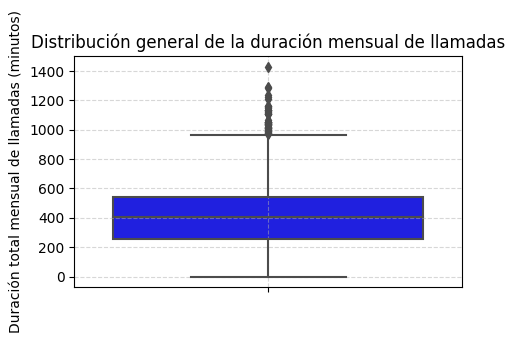

In [ ]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

plt.figure(figsize=(5, 3))
sns.boxplot(y='total_monthly_duration', data= monthly_minutes, color='blue')

plt.title('Distribución general de la duración mensual de llamadas')
plt.ylabel('Duración total mensual de llamadas (minutos)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]
El plan surf es uno de los más solicitados a la hora de adquirir un operador, los usuarios al conocer los limites de su plan procuran mantener el consumo para no excedense en valores adicionales. En relación con el gráfico, este muestra una simetría en sus datos indicando una dispersión en los datos aproximadamente entre 220 a 580 y una media de 400 minutos en total. Los bigotes que se extienden desde el Q3 hasta el valor máximo estan entre un rango de 580 hasta un poco menos de los 1000 minutos, mientras que el Q1 se establece desde 0 hasta 220 aproximadamente. Los valores atípicos que estan alejados del Q4, representan la duración en llamadas por encima de los 1000 minutos.

### Mensajes

In [ ]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], errors='coerce')
df_messages['month'] = df_messages['message_date'].dt.month

messages_users = pd.merge(df_messages,df_users, on='user_id', how='left')
messages_per_user_month = (messages_users.groupby(['user_id', 'plan', 'month'])['id'].count().reset_index(name='messages_count'))

display(messages_per_user_month.head())

,user_id,plan,month,messages_count
0,1000,ultimate,12,11
1,1001,surf,8,30
2,1001,surf,9,44
3,1001,surf,10,53
4,1001,surf,11,36


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]
El plan que tiene mayor consumo de mensajes es surf, depende del mes en que el los usuarios envien más mensajes, pero en términos generales esta dentro del rango de 30 a 50 mensajes aproximadamente

### Internet

In [ ]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
internet_users = pd.merge(df_internet,df_users, on='user_id', how='left')

monthly_internet = (internet_users.groupby(['user_id', 'plan', 'month'])['gb_used'].sum().reset_index(name='total_gb_used'))

average_internet_plan_month = monthly_internet[['user_id', 'plan', 'month', 'total_gb_used']]
display(average_internet_plan_month)


,user_id,plan,month,total_gb_used
0,1000,ultimate,12,1.8569
1,1001,surf,8,6.7570
2,1001,surf,9,13.0027
3,1001,surf,10,21.8072
4,1001,surf,11,18.0706
...,...,...,...,...
2272,1498,surf,12,22.5954
2273,1499,surf,9,12.6803
2274,1499,surf,10,19.0355
2275,1499,surf,11,16.4198


[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?] El comportamiento del consumo de internet depende del plan y el mas usado es el plan surf y por ende representa más consumo.

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [ ]:
full_users_ajustado_2["ingreso_mensual"].describe()

count    2293.000000
mean      291.328796
std       175.792931
min        20.000000
25%       154.000000
50%       280.360000
75%       410.000000
max      1250.270000
Name: ingreso_mensual, dtype: float64

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

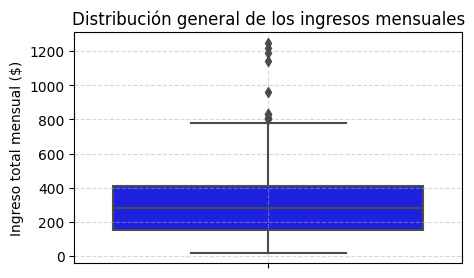

In [ ]:
#diagrama de caja
plt.figure(figsize=(5, 3))
sns.boxplot(y='ingreso_mensual', data=full_users_ajustado_2, color='blue')

plt.title('Distribución general de los ingresos mensuales')
plt.ylabel('Ingreso total mensual ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
La mayoria de los ingresos de los usuarios esta entre el rango de 200 a 400 por el consumo de su plan de preferencia.
Tambien se evidencias datos atipicos por encima de los 800, es decir, que su consumo esta muy por encima de su plan base,
puede ser debido principalmente al aumento en el consumo de internet, que en terminos de tarifas adicionales, es el mas
significativo.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

- Recomiendo mostrar los datos de una manera similar a `llamadas`, así se mantiene una consistencia similar a lo largo del proyecto
</div>


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [ ]:
# Prueba las hipótesis
surf = full_users_ajustado_2.loc[full_users_ajustado_2['plan'] == 'surf', 'ingreso_mensual'].astype(float)
ultimate = full_users_ajustado_2.loc[full_users_ajustado_2['plan'] == 'ultimate', 'ingreso_mensual'].astype(float)

alpha = .05

results = st.ttest_ind(surf, ultimate, equal_var=True)

print("Valor p:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se puede rechazar la hipótesis nula")

print("Promedio de ingreso del plan Surf:", surf.mean())
print("Promedio de ingreso del plan Ultimate:", ultimate.mean())

Valor p: 3.4685075558098333e-68
Rechazamos la hipótesis nula
Promedio de ingreso del plan Surf: 333.2809472345836
Promedio de ingreso del plan Ultimate: 199.675


con el 3.4685 x 10 a la -68, rechazamos la hipotesis nula donde la media de ingreso por usuario del plan surf
es igual a la media del ingreso por usuario del plan ultimate.


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [ ]:
# Prueba las hipótesis
income_by_city = full_users_ajustado_2.merge(full_users_ajustado_2[["user_id", "city"]], on="user_id",how="left")

ny_nj = full_users_ajustado_2["city"].str.contains("NY-NJ", na=False)
NY_income = full_users_ajustado_2.loc[ny_nj, "ingreso_mensual"].astype(float)
other_cities = full_users_ajustado_2.loc[~ny_nj, "ingreso_mensual"].astype(float)
alpha = 0.05

results = st.ttest_ind(NY_income, other_cities, equal_var=False)

print("Valor p:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No se puede rechazar la hipótesis nula")

# Promedios
print("Promedio ingreso NY-NJ:", NY_income.mean())
print("Promedio ingreso otras ciudades:", other_cities.mean())

Valor p: 0.0016361803539600994
Rechazamos la hipótesis nula
Promedio ingreso NY-NJ: 316.78371352785143
Promedio ingreso otras ciudades: 286.3201826722338


In [ ]:
con el 0,16% podemos rechazar la hipotesis nula donde la media del ingreso por usuario en NY-NJ es igual a la media
del ingreso por usuario de las demas ciudades.

## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]
- Principalmente los usuarios de telefonía prefieren el plan surf a comparación del plan ultimate.
- Los usuarios prefieren usar el servicio de internet en relación con realizar llamadas o enviar mensajes, por ende el sobrecosto en el plan se debe principalmente al consumo de internet.
- El sobrecosto mencionado anteriormente, es debido a que los usuarios prefieren un plan mas barato, sin embargo, dado el alto consumo de internet que no esta dentro de su plan, incrementa considerablemente el valor a pagar al final del mes.
